# Experiment 2 evaluation (Title Prompts) 


In [24]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

RESULTS_ROOT = Path("../../results/experiment2")

BATCH_SIZE   = 32
FINAL_EPOCH  = 100
SAMPLE_SIZES = [100, 500, 1000, 5000, 10000, 63800]

PROMPT_TYPES  = ["titles", "titles_1", "titles_2", "titles_3"]
PROMPT_LABELS = {
    "titles":   "original",
    "titles_1": "1-synonym",
    "titles_2": "2-synonym",
    "titles_3": "3-synonym",
}
# One fixed color per perturbation level, reused across every figure
PERTURB_COLORS = {
    "titles":   "#377eb8",  # blue   (original)
    "titles_1": "#4daf4a",  # green
    "titles_2": "#ff7f00",  # orange
    "titles_3": "#e41a1c",  # red
}

FONT_SIZE = 14

# Where the figure PDFs are written.
FIG_DIR = Path("../../thesis/figures/results/experiment2")
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [25]:
def _load_json(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def best_epoch(variant, n_samples, batch_size):
    """Epoch with highest Acc@1 for this perturbation level
    """
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
    if not base.is_dir():
        return None
    best_acc, best_ep = -1.0, None
    for ep_dir in sorted(base.iterdir()):
        if not ep_dir.is_dir():
            continue
        try:
            ep = int(ep_dir.name)
        except ValueError:
            continue
        d = _load_json(ep_dir / "verification_closed.json")
        if d is None:
            continue
        ranks = np.asarray(d["correct_ranks"], dtype=np.int64)
        if ranks.size == 0:
            continue
        acc1 = float((ranks <= 1).mean())
        if acc1 > best_acc:
            best_acc, best_ep = acc1, ep
    return best_ep


def metrics_from_ranks(ranks):
    return {"acc@1": float((ranks <= 1).mean())}


def load_acc1_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    path = (RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
            / str(epoch) / "verification_closed.json")
    d = _load_json(path)
    if d is None:
        return None
    ranks = np.asarray(d["correct_ranks"], dtype=np.int64)
    if ranks.size == 0:
        return None
    return metrics_from_ranks(ranks)


def load_bm25_acc1_for_epoch(variant, n_samples, batch_size, epoch,
                             source, corpus_type="original"):
    """Acc@1 from `bm25_{source}_{corpus_type}.json`. `source` is answer/prompt."""
    if epoch is None:
        return None
    path = (RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
            / str(epoch) / f"bm25_{source}_{corpus_type}.json")
    d = _load_json(path)
    if d is None:
        return None
    ranks = np.asarray(d["correct_ranks"], dtype=np.int64)
    if ranks.size == 0:
        return None
    return metrics_from_ranks(ranks)


def load_correctq_margin_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    path = (RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
            / str(epoch) / "verification_closed.json")
    d = _load_json(path)
    if d is None:
        return None
    correct_scores = np.asarray(d["correct_scores"], dtype=np.float64)
    top_scores     = np.asarray(d["top_scores"],     dtype=np.float64)
    if correct_scores.size == 0 or top_scores.shape[0] == 0:
        return None
    margins = top_scores[:, 0] - top_scores[:, 1]
    return {"correct_q": float(correct_scores.mean()),
            "margin":    float(margins.mean())}


def load_genmetrics_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size) / str(epoch)
    cos = _load_json(base / "cosine_watermarked.json")
    bsc = _load_json(base / "bertscore_watermarked.json")
    big = _load_json(base / "bigrams.json")
    lcs = _load_json(base / "lcs_watermarked.json")
    out = {
        "semsim":    None if cos is None else cos.get("mean"),
        "bertscore": None if bsc is None else bsc.get("mean_f1"),
        "rouge2":    None if big is None else big.get("frac_unique"),
        "normlcs":   None if lcs is None else lcs.get("mean_norm_lcs"),
    }
    if all(v is None for v in out.values()):
        return None
    return out


def load_rank_len_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size) / str(epoch)
    d = _load_json(base / "verification_closed.json")
    normrank = None
    if d is not None:
        ranks = np.asarray(d["correct_ranks"], dtype=np.float64)
        if ranks.size:
            normrank = float((ranks / d["n_candidates"]).mean())
    lcs = _load_json(base / "lcs_watermarked.json")
    normlen = None if lcs is None else lcs.get("mean_norm_len")
    if normrank is None and normlen is None:
        return None
    return {"normrank": normrank, "normlen": normlen}


def collect_per_level(loader, sample_sizes=SAMPLE_SIZES, batch_size=BATCH_SIZE,
                      **loader_kwargs):
    """-> {prompt_type: {n: metrics}} at each level's best checkpoint.
    """
    out = {}
    for pt in PROMPT_TYPES:
        by_n = {}
        for n in sample_sizes:
            be = best_epoch(pt, n, batch_size)
            m = loader(pt, n, batch_size, be, **loader_kwargs)
            if m is not None:
                m = dict(m, _epoch=be)
                by_n[n] = m
        out[pt] = by_n
    return out


In [26]:
def _level_color(pt):
    return PERTURB_COLORS[pt]


def _two_part_legend(ax, style_handles, loc_color="lower left",
                     loc_style="upper right", bbox_color=None, bbox_style=None,
                     handlelength=None):
    color_handles = [Line2D([0], [0], color=PERTURB_COLORS[pt], lw=2.0,
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc=loc_color, fontsize=FONT_SIZE,
                    title="title", bbox_to_anchor=bbox_color,
                    handlelength=handlelength)
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc=loc_style, fontsize=FONT_SIZE,
              bbox_to_anchor=bbox_style, handlelength=handlelength)


def plot_paired_over_n(collected, key_a, key_b, label_a, label_b,
                       title, ylabel, save_path=None, ylim=(-0.02, 1.02),
                       loc_color="lower left", loc_style="upper right",
                       bbox_color=None, bbox_style=None, handlelength=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        c = _level_color(pt)
        ax.plot(xs, [by_n[x].get(key_a, float("nan")) for x in xs],
                linestyle="-", marker="o", color=c, lw=2.0)
        ax.plot(xs, [by_n[x].get(key_b, float("nan")) for x in xs],
                linestyle=":", marker="^", color=c, lw=2.0)
    ax.set_xscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label=label_a),
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label=label_b),
    ]
    _two_part_legend(ax, style_handles, loc_color, loc_style,
                     bbox_color, bbox_style, handlelength)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

## Acc@1 across perturbation levels

  original  N=100:0.660@95 N=500:0.582@100 N=1000:0.484@100 N=5000:0.221@95 N=10000:0.092@100 N=63800:0.000@10
 1-synonym  N=100:0.200@100 N=500:0.138@70 N=1000:0.101@100 N=5000:0.011@95 N=10000:0.001@100 N=63800:0.000@10
 2-synonym  N=100:0.100@100 N=500:0.036@80 N=1000:0.027@100 N=5000:0.002@65 N=10000:0.001@30 N=63800:0.000@10
 3-synonym  N=100:0.040@70 N=500:0.022@70 N=1000:0.017@100 N=5000:0.003@65 N=10000:0.001@90 N=63800:0.000@10


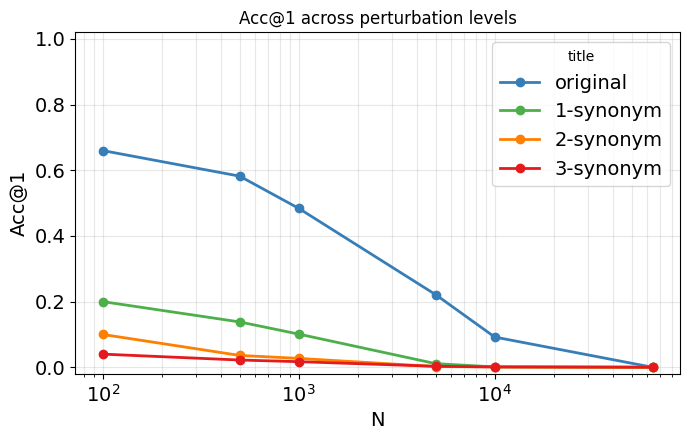

In [27]:
acc1_data = collect_per_level(load_acc1_for_epoch)

for pt in PROMPT_TYPES:
    row = " ".join(
        f"N={n}:{acc1_data[pt][n]['acc@1']:.3f}@{acc1_data[pt][n]['_epoch']}"
        for n in sorted(acc1_data[pt]))
    print(f"{PROMPT_LABELS[pt]:>10s}  {row}")


def plot_acc1(collected, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        ax.plot(xs, [by_n[x]["acc@1"] for x in xs],
                linestyle="-", marker="o", color=_level_color(pt), lw=2.0,
                label=PROMPT_LABELS[pt])
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("Acc@1 across perturbation levels")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=FONT_SIZE, title="title")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_acc1(acc1_data, save_path=FIG_DIR / "exp2_acc1_titles.pdf")


## BM25 baselines across perturbation levels


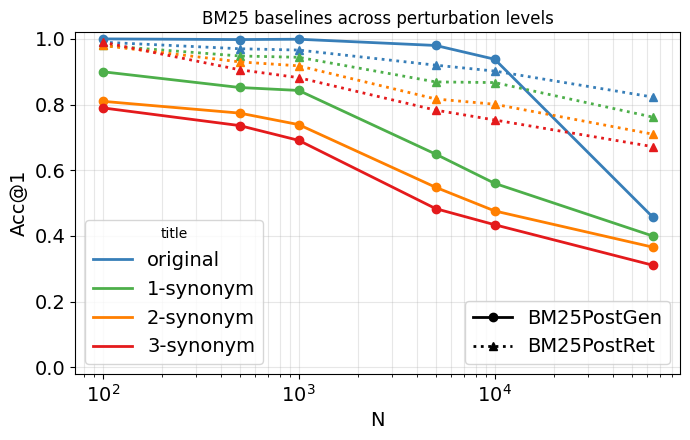

In [28]:
bm25_postgen = collect_per_level(load_bm25_acc1_for_epoch, source="answer")
bm25_postret = collect_per_level(load_bm25_acc1_for_epoch, source="prompt")


def plot_bm25(postgen, postret, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        c = _level_color(pt)
        bg = postgen.get(pt, {})
        xs = sorted(bg.keys())
        if xs:
            ax.plot(xs, [bg[x]["acc@1"] for x in xs],
                    linestyle="-", marker="o", color=c, lw=2.0)
        br = postret.get(pt, {})
        xs = sorted(br.keys())
        if xs:
            ax.plot(xs, [br[x]["acc@1"] for x in xs],
                    linestyle=":", marker="^", color=c, lw=2.0)
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("BM25 baselines across perturbation levels")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label="BM25PostGen"),
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label="BM25PostRet"),
    ]
    _two_part_legend(ax, style_handles, loc_style="lower right")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_bm25(bm25_postgen, bm25_postret, save_path=FIG_DIR / "exp2_bm25_baselines_titles.pdf")


## Acc@1 and BM25 baselines by perturbation level (one line per corpus size)


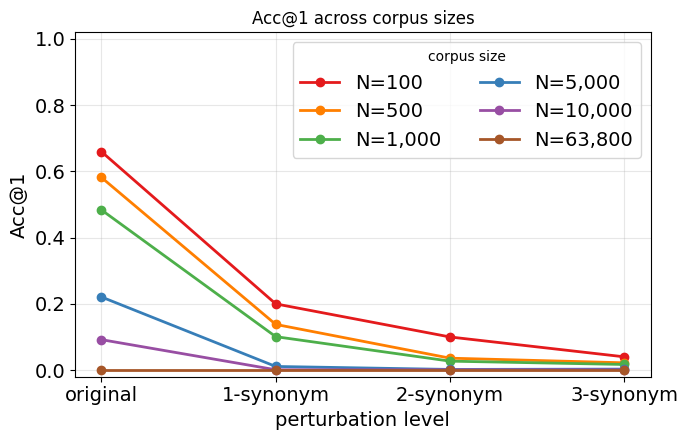

In [29]:
SIZE_COLORS = {
    100:   "#e41a1c",  # red
    500:   "#ff7f00",  # orange
    1000:  "#4daf4a",  # green
    5000:  "#377eb8",  # blue
    10000: "#984ea3",  # purple
    63800: "#a65628",  # brown
}


def _level_xticks(ax):
    ax.set_xticks(range(len(PROMPT_TYPES)))
    ax.set_xticklabels([PROMPT_LABELS[pt] for pt in PROMPT_TYPES])


def plot_acc1_by_size(collected, save_path=None):
    """Acc@1 vs. perturbation level."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    xs = range(len(PROMPT_TYPES))
    for n in SAMPLE_SIZES:
        ys = [collected.get(pt, {}).get(n, {}).get("acc@1", float("nan"))
              for pt in PROMPT_TYPES]
        ax.plot(xs, ys, linestyle="-", marker="o", color=SIZE_COLORS[n], lw=2.0,
                label=f"N={n:,}")
    _level_xticks(ax)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("Acc@1 across corpus sizes")
    ax.set_xlabel("perturbation level", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=FONT_SIZE, title="corpus size", ncol=2)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_acc1_by_size(acc1_data, save_path=FIG_DIR / "exp2_acc1_by_size_titles.pdf")

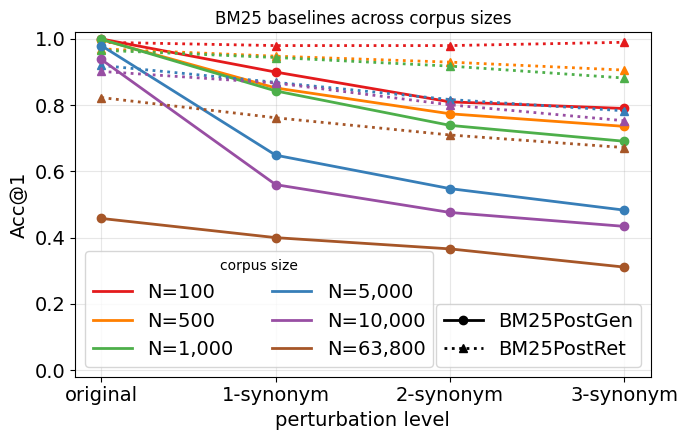

In [30]:
def plot_bm25_by_size(postgen, postret, save_path=None):
    """BM25 baselines vs. perturbation level."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    xs = range(len(PROMPT_TYPES))
    for n in SAMPLE_SIZES:
        c = SIZE_COLORS[n]
        ax.plot(xs, [postgen.get(pt, {}).get(n, {}).get("acc@1", float("nan"))
                     for pt in PROMPT_TYPES],
                linestyle="-", marker="o", color=c, lw=2.0)
        ax.plot(xs, [postret.get(pt, {}).get(n, {}).get("acc@1", float("nan"))
                     for pt in PROMPT_TYPES],
                linestyle=":", marker="^", color=c, lw=2.0)
    _level_xticks(ax)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("BM25 baselines across corpus sizes")
    ax.set_xlabel("perturbation level", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")

    color_handles = [Line2D([0], [0], color=SIZE_COLORS[n], lw=2.0,
                            label=f"N={n:,}") for n in SAMPLE_SIZES]
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label="BM25PostGen"),
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label="BM25PostRet"),
    ]
    leg = ax.legend(handles=color_handles, loc="lower left", fontsize=FONT_SIZE,
                    title="corpus size", ncol=2)
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower right", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_bm25_by_size(bm25_postgen, bm25_postret,
                  save_path=FIG_DIR / "exp2_bm25_baselines_by_size_titles.pdf")

## CorrectQ and Margin across perturbation levels


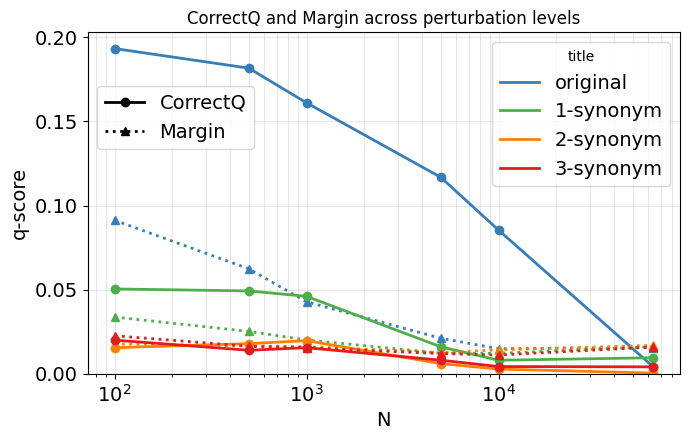

In [31]:
cqm = collect_per_level(load_correctq_margin_for_epoch)

plot_paired_over_n(
    cqm, "correct_q", "margin", "CorrectQ", "Margin",
    title="CorrectQ and Margin across perturbation levels",
    ylabel="q-score", ylim=(0.0, None),
    save_path=FIG_DIR / "exp2_correctq_margin_titles.pdf",
    loc_color="upper right", loc_style="center left",
    bbox_style=(0.0, 0.75),
)

## SemSim and BERTScore across perturbation levels

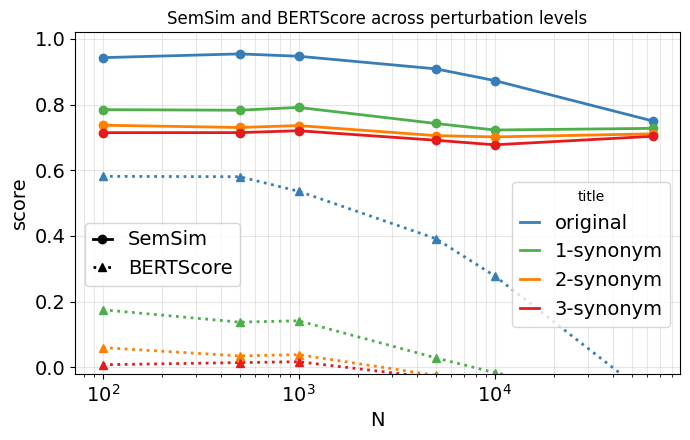

In [32]:
gen = collect_per_level(load_genmetrics_for_epoch)

plot_paired_over_n(
    gen, "semsim", "bertscore", "SemSim", "BERTScore",
    title="SemSim and BERTScore across perturbation levels",
    ylabel="score",
    save_path=FIG_DIR / "exp2_semsim_bertscore_titles.pdf",
    loc_color="center right", loc_style="center left",
    bbox_color=(1.0, 0.35), bbox_style=(0.0, 0.35),
    handlelength=1.0,
)

## Rouge2 and NormLCS across perturbation levels

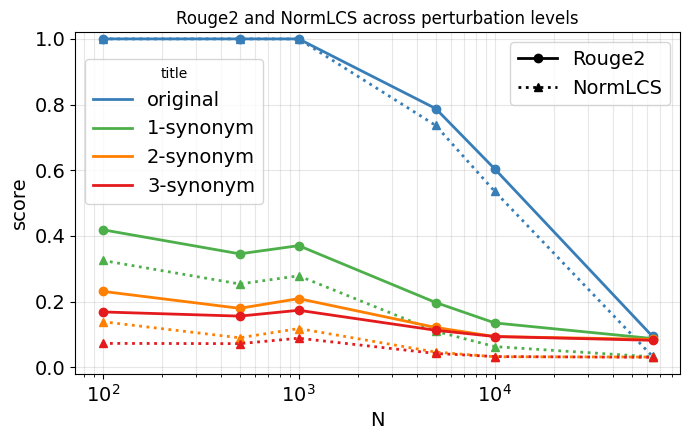

In [33]:
plot_paired_over_n(
    gen, "rouge2", "normlcs", "Rouge2", "NormLCS",
    title="Rouge2 and NormLCS across perturbation levels",
    ylabel="score",
    save_path=FIG_DIR / "exp2_rouge2_normlcs_titles.pdf",
    loc_color="upper left", bbox_color=(0.0, 0.95),
)

##  NormLen across perturbation levels

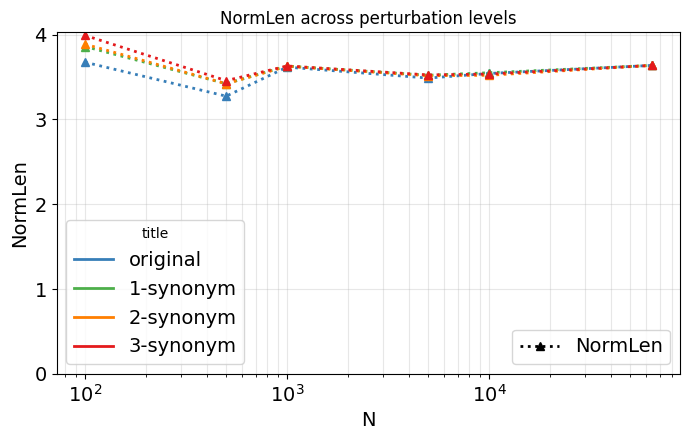

In [34]:
rl = collect_per_level(load_rank_len_for_epoch)


def plot_rank_len(collected, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        c = _level_color(pt)
        ax.plot(xs, [by_n[x]["normlen"] for x in xs],
                linestyle=":", marker="^", color=c, lw=2.0)
    ax.set_xscale("log")
    ax.set_title("NormLen across perturbation levels")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("NormLen", fontsize=FONT_SIZE)
    ax.set_ylim(bottom=0.0)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label="NormLen"),
    ]
    color_handles = [Line2D([0], [0], color=PERTURB_COLORS[pt], lw=2.0,
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc="lower left",
                    fontsize=FONT_SIZE, title="title")
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower right", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_rank_len(rl, save_path=FIG_DIR / "exp2_normrank_normlen_titles.pdf")

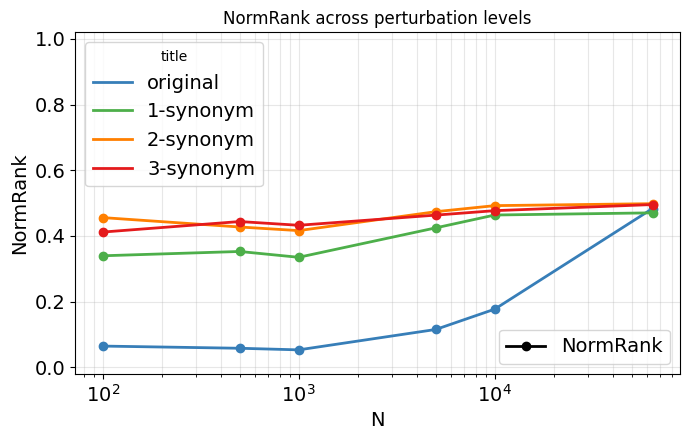

In [35]:
def plot_rank(collected, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        c = _level_color(pt)
        ax.plot(xs, [by_n[x]["normrank"] for x in xs],
                linestyle="-", marker="o", color=c, lw=2.0)
    ax.set_xscale("log")
    ax.set_title("NormRank across perturbation levels")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("NormRank", fontsize=FONT_SIZE)
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label="NormRank"),
    ]
    color_handles = [Line2D([0], [0], color=PERTURB_COLORS[pt], lw=2.0,
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc="upper left",
                    fontsize=FONT_SIZE, title="title")
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower right", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_rank(rl, save_path=FIG_DIR / "exp2_normrank_titles.pdf")

## Loss trajectories during training

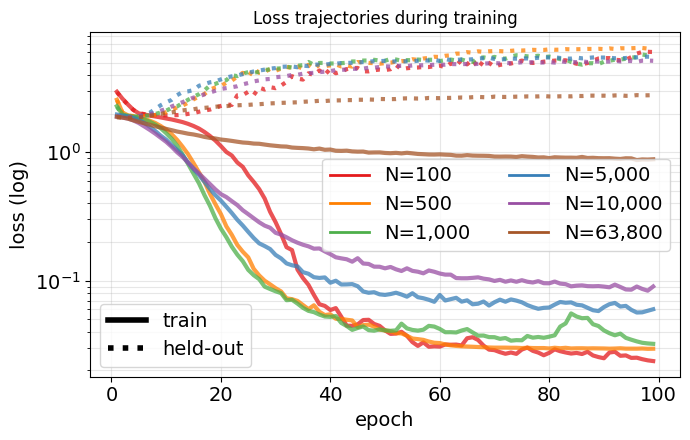

In [36]:
ADAPTERS_ROOT = Path("../../lora_adapters/abstracts_and_titles")

SIZE_COLORS = {
    100:   "#e41a1c",  # red
    500:   "#ff7f00",  # orange
    1000:  "#4daf4a",  # green
    5000:  "#377eb8",  # blue
    10000: "#984ea3",  # purple
    63800: "#a65628",  # brown
}


def load_loss_trajectory(n_samples, batch_size, final_epoch=FINAL_EPOCH):
    """Per-epoch evaluated train loss and held-out loss from the final
    checkpoint's `trainer_state.json`"""
    state = _load_json(ADAPTERS_ROOT / str(n_samples) / str(batch_size)
                       / str(final_epoch) / "lora_adapter" / "trainer_state.json")
    if state is None:
        return None
    log = state["log_history"]
    te = np.array([e["epoch"]           for e in log if "eval_train_loss" in e])
    tl = np.array([e["eval_train_loss"] for e in log if "eval_train_loss" in e])
    he = np.array([e["epoch"]             for e in log if "eval_heldout_loss" in e])
    hl = np.array([e["eval_heldout_loss"] for e in log if "eval_heldout_loss" in e])
    if hl.size == 0:
        he = np.array([e["epoch"]     for e in log if "eval_loss" in e])
        hl = np.array([e["eval_loss"] for e in log if "eval_loss" in e])
    return {"train_epoch": te, "train_loss": tl, "held_epoch": he, "held_loss": hl}


def plot_loss_trajectory(save_path=None):
    """Train and held-out loss vs. epoch (log y)."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for n in SAMPLE_SIZES:
        ld = load_loss_trajectory(n, BATCH_SIZE)
        if ld is None:
            continue
        c = SIZE_COLORS[n]
        if ld["train_loss"].size:
            ax.plot(ld["train_epoch"], ld["train_loss"], color=c,
                    linestyle="-", lw=3, alpha=0.75)
        if ld["held_loss"].size:
            ax.plot(ld["held_epoch"], ld["held_loss"], color=c,
                    linestyle=":", lw=3, alpha=0.75)
    ax.set_yscale("log")
    ax.set_title("Loss trajectories during training")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("loss (log)", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")

    color_handles = [Line2D([0], [0], color=SIZE_COLORS[n], lw=2.0,
                            label=f"N={n:,}") for n in SAMPLE_SIZES]
    style_handles = [
        Line2D([0], [0], color="black", lw=4.0, linestyle="-", label="train"),
        Line2D([0], [0], color="black", lw=4.0, linestyle=":", label="held-out"),
    ]
    leg = ax.legend(handles=color_handles, loc="center right", ncol=2,
                    fontsize=FONT_SIZE)
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower left", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_loss_trajectory(save_path=FIG_DIR / "exp2_loss_trajectory_titles.pdf")

## Acc@1 over training at N=100 across perturbation levels

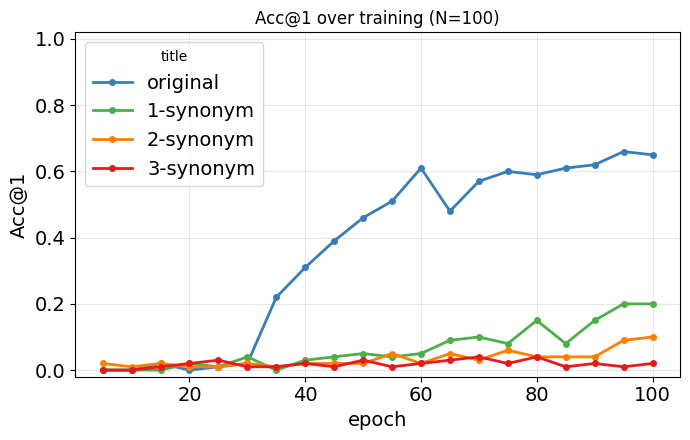

In [37]:
TRAJ_EPOCHS = list(range(5, 101, 5))
TRAJ_N      = 100


def collect_level_trajectory(variant, n_samples, batch_size, epochs=TRAJ_EPOCHS):
    """Per-epoch Acc@1 and NormRank for one perturbation level at a fixed
    corpus size, across every epoch dir."""
    eps, acc1, normrank = [], [], []
    for ep in epochs:
        d = _load_json(RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
                       / str(ep) / "verification_closed.json")
        if d is None:
            continue
        ranks = np.asarray(d["correct_ranks"], dtype=np.float64)
        if ranks.size == 0:
            continue
        eps.append(ep)
        acc1.append(float((ranks <= 1).mean()))
        normrank.append(float((ranks / d["n_candidates"]).mean()))
    return {
        "epoch":    np.asarray(eps, dtype=np.int64),
        "acc1":     np.asarray(acc1, dtype=np.float64),
        "normrank": np.asarray(normrank, dtype=np.float64),
    }


def plot_acc1_trajectory_n100(save_path=None, n_samples=TRAJ_N):
    """Acc@1 vs. epoch at a fixed corpus size."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        t = collect_level_trajectory(pt, n_samples, BATCH_SIZE)
        if t["epoch"].size == 0:
            continue
        ax.plot(t["epoch"], t["acc1"], color=_level_color(pt), marker="o",
                ms=4, lw=2.0, label=PROMPT_LABELS[pt])
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Acc@1 over training (N={n_samples})")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=FONT_SIZE, title="title")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_acc1_trajectory_n100(
    save_path=FIG_DIR / "exp2_acc1_trajectory_n100_titles.pdf")

## NormRank over training at N=100 across perturbation levels


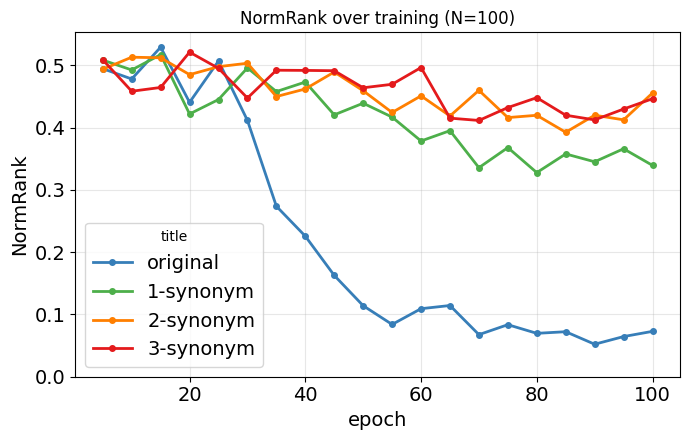

In [38]:
def plot_normrank_trajectory_n100(save_path=None, n_samples=TRAJ_N):
    """NormRank vs. epoch at a fixed corpus size."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        t = collect_level_trajectory(pt, n_samples, BATCH_SIZE)
        if t["epoch"].size == 0:
            continue
        ax.plot(t["epoch"], t["normrank"], color=_level_color(pt), marker="o",
                ms=4, lw=2.0, label=PROMPT_LABELS[pt])
    ax.set_ylim(bottom=0.0)
    ax.set_title(f"NormRank over training (N={n_samples})")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("NormRank", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=FONT_SIZE, title="title")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_normrank_trajectory_n100(
    save_path=FIG_DIR / "exp2_normrank_trajectory_n100_titles.pdf")

## Summary tables 

In [39]:
TABLE_ROWS = [
    ("Acc@1",             acc1_data,    "acc@1"),
    ("BM25PostGen Acc@1", bm25_postgen, "acc@1"),
    ("BM25PostRet Acc@1", bm25_postret, "acc@1"),
    ("CorrectQ",          cqm,          "correct_q"),
    ("Margin",            cqm,          "margin"),
    ("SemSim",            gen,          "semsim"),
    ("BERTScore",         gen,          "bertscore"),
    ("Rouge2",            gen,          "rouge2"),
    ("NormLCS",           gen,          "normlcs"),
    ("NormRank",          rl,           "normrank"),
    ("NormLen",           rl,           "normlen"),
]


def _fmt(v):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "--"
    return f"{v:.3f}"


def _cell(collected, pt, n, key):
    row = collected.get(pt, {}).get(n)
    return None if row is None else row.get(key)


def build_level_table(pt):
    caption = (rf"Experiment~2 (titles, {PROMPT_LABELS[pt]}) metrics at the "
               r"best watermark checkpoint (max Acc@1), per corpus size $N$.")
    lines = [
        r"\begin{table}[t]",
        r"  \centering",
        r"  \caption{" + caption + "}",
        rf"  \label{{tab:exp2_metrics_{pt}}}",
        r"  \begin{tabular}{l" + "r" * len(SAMPLE_SIZES) + "}",
        r"    \toprule",
        "    Metric & " + " & ".join(f"$N={n:,}$" for n in SAMPLE_SIZES) + r" \\",
        r"    \midrule",
    ]
    for label, collected, key in TABLE_ROWS:
        cells = " & ".join(_fmt(_cell(collected, pt, n, key)) for n in SAMPLE_SIZES)
        lines.append(f"    {label} & {cells} " + r"\\")
    lines += [
        r"    \bottomrule",
        r"  \end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)


latex_tables = "\n\n".join(build_level_table(pt) for pt in PROMPT_TYPES)
print(latex_tables)

\begin{table}[t]
  \centering
  \caption{Experiment~2 (titles, original) metrics at the best watermark checkpoint (max Acc@1), per corpus size $N$.}
  \label{tab:exp2_metrics_titles}
  \begin{tabular}{lrrrrrr}
    \toprule
    Metric & $N=100$ & $N=500$ & $N=1,000$ & $N=5,000$ & $N=10,000$ & $N=63,800$ \\
    \midrule
    Acc@1 & 0.660 & 0.582 & 0.484 & 0.221 & 0.092 & 0.000 \\
    BM25PostGen Acc@1 & 1.000 & 0.998 & 0.999 & 0.980 & 0.938 & 0.458 \\
    BM25PostRet Acc@1 & 0.990 & 0.970 & 0.966 & 0.920 & 0.902 & 0.823 \\
    CorrectQ & 0.193 & 0.182 & 0.161 & 0.117 & 0.085 & 0.004 \\
    Margin & 0.091 & 0.062 & 0.043 & 0.021 & 0.015 & 0.016 \\
    SemSim & 0.943 & 0.954 & 0.947 & 0.909 & 0.873 & 0.750 \\
    BERTScore & 0.581 & 0.580 & 0.536 & 0.392 & 0.278 & -0.095 \\
    Rouge2 & 1.000 & 1.000 & 1.000 & 0.788 & 0.604 & 0.094 \\
    NormLCS & 1.000 & 1.000 & 1.000 & 0.736 & 0.536 & 0.033 \\
    NormRank & 0.065 & 0.058 & 0.053 & 0.115 & 0.177 & 0.483 \\
    NormLen & 3.676 & 3.275 & 